# Flux Fiction accuracy controls: system latency and Fluxion base

This report isolates the two requested accuracy factors using the
policy-specific 500-job Salishan Gaussian traces:

- `account_system_latency = true` versus `false`
- current v0.53-derived Fluxion versus reconstructed v0.48

Submission stays asynchronous. All jobspecs include cores. Easy and
Conservative reservation depth are not experimental factors; the
frozen Salishan scheduler configurations are used unchanged. Hybrid
uses reservation depth 4. Fluxion is Release/O3 with DFTracer level 2.
Each pdebug allocation runs one current/v0.48 pair concurrently.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display
from plotnine import (
    aes, element_text, facet_wrap, geom_col, geom_hline, ggplot,
    labs, position_dodge, scale_fill_manual, theme, theme_bw,
)

ROOT = Path('/p/lustre5/ashworth12/dftracer-accuracy-controls-20260730_062820')
payload = json.loads((ROOT / 'reports' / 'accuracy_controls.json').read_text())
assert payload['complete']
assert payload['all_traces_valid']
runs = pd.DataFrame(payload['runs'])
runs['latency_setting'] = runs['account_system_latency'].map({
    True: 'account latency on', False: 'account latency off'
})
runs['policy'] = pd.Categorical(
    runs['policy'], ['easy', 'conservative', 'hybrid'], ordered=True
)
assert len(runs) == 12
assert (runs['state'] == 'succeeded').all()
assert (runs['simulated_jobs'] == 500).all()
assert (runs['run_match_events_with_jobid'] > 0).all()
display(runs[[
    'policy', 'scheduler_base', 'account_system_latency',
    'notebook_utilization_error_pct_points',
    'utilization_curve_mae_pct_points', 'wall_seconds',
    'run_match_events_with_jobid', 'accuracy_pass_1pp',
]].sort_values(['policy', 'account_system_latency', 'scheduler_base']).round(3))


,policy,scheduler_base,account_system_latency,notebook_utilization_error_pct_points,utilization_curve_mae_pct_points,wall_seconds,run_match_events_with_jobid,accuracy_pass_1pp
3,easy,v048,False,0.174,5.202,186.0,24867,True
2,easy,v053,False,0.174,5.202,191.0,24867,True
1,easy,v048,True,1.385,7.845,165.0,23827,False
0,easy,v053,True,1.385,7.845,166.0,23827,False
7,conservative,v048,False,0.225,6.227,890.0,32516,True
6,conservative,v053,False,0.225,6.232,927.0,32567,True
5,conservative,v048,True,0.240,6.442,909.0,32422,True
4,conservative,v053,True,0.240,6.442,953.0,32422,True
11,hybrid,v048,False,1.064,9.659,289.0,25723,False
10,hybrid,v053,False,0.441,8.176,271.0,25007,True


## Accuracy result

The dashed line is the Gaussian acceptance threshold used by the
Salishan suite: 1 percentage point of notebook-equivalent mean
utilization error. Shorter bars are more accurate.


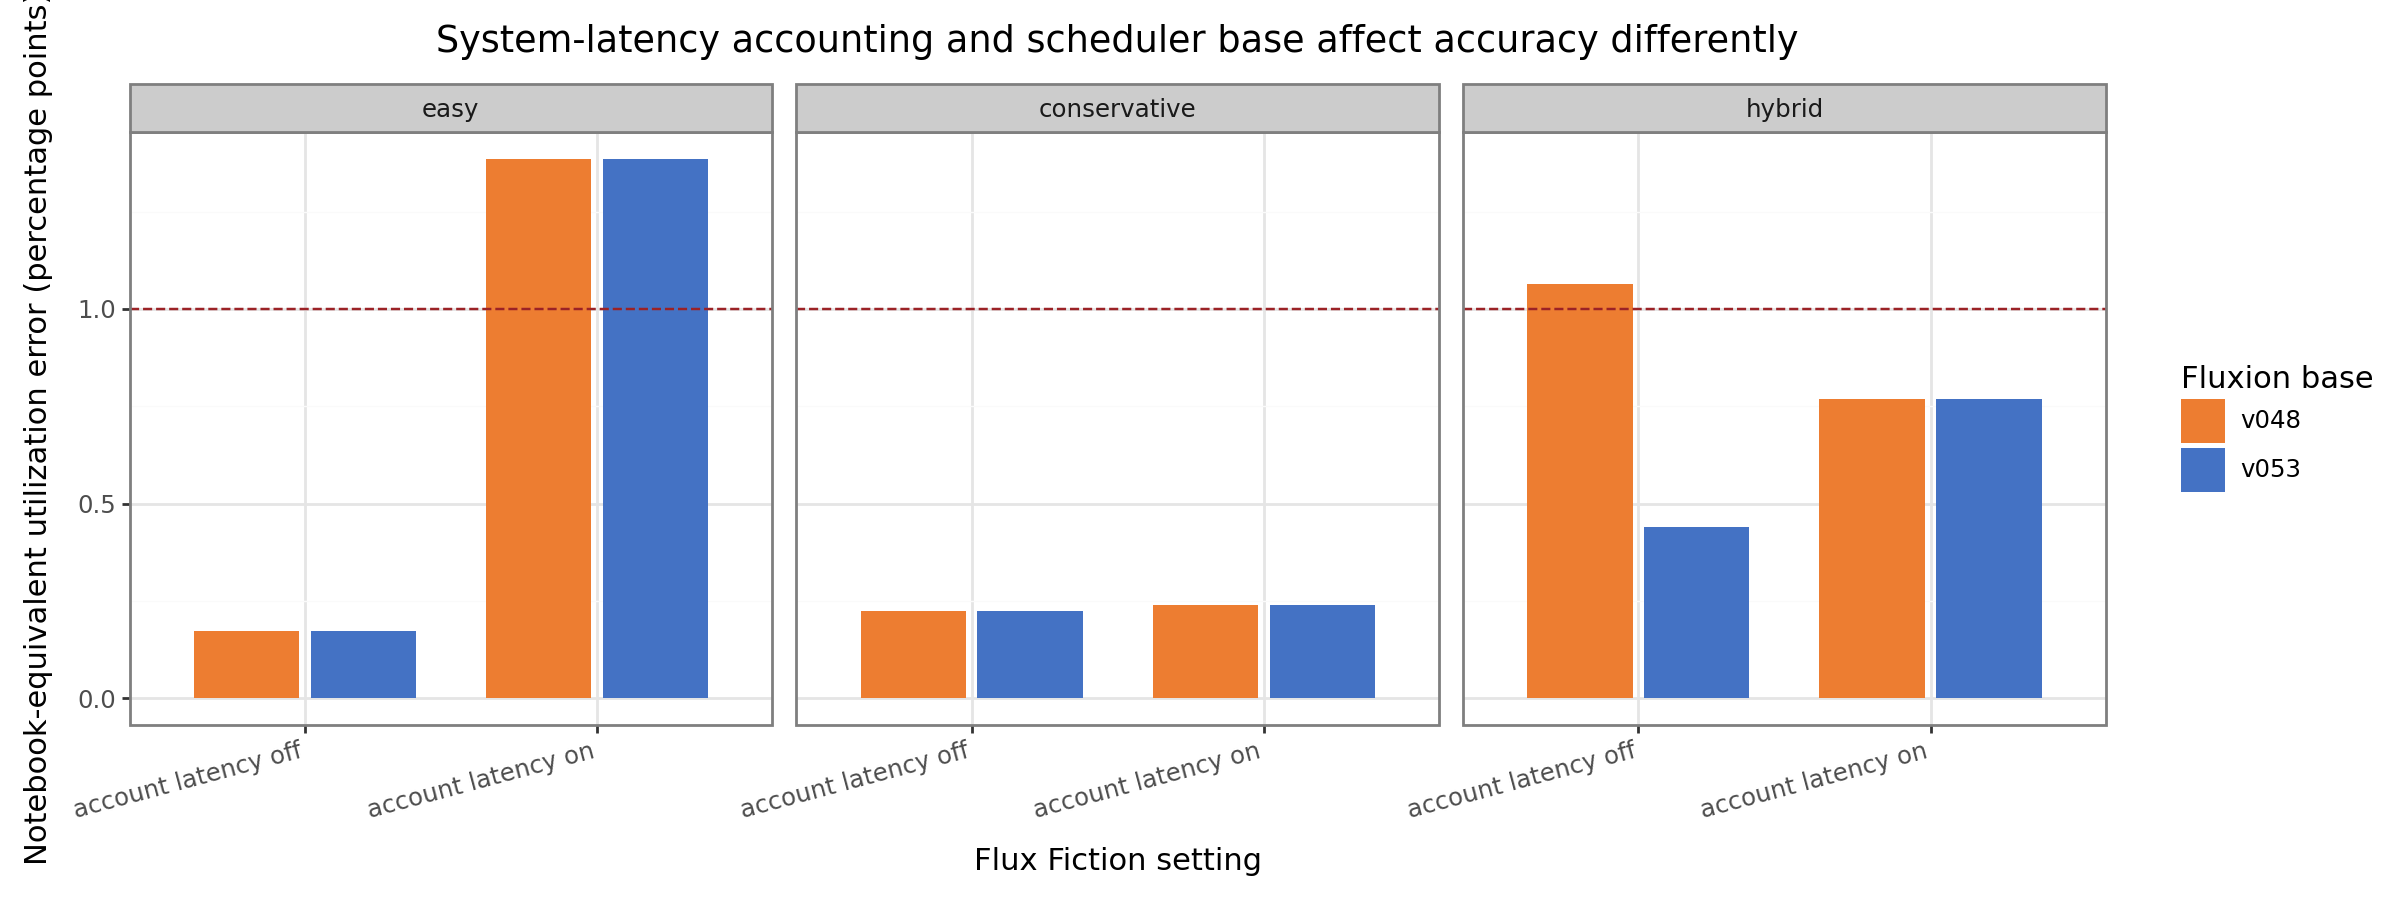

In [2]:
(
    ggplot(
        runs,
        aes(
            x='latency_setting',
            y='notebook_utilization_error_pct_points',
            fill='scheduler_base',
        ),
    )
    + geom_col(position=position_dodge(width=0.8), width=0.72)
    + geom_hline(yintercept=1.0, linetype='dashed', color='#9B2226')
    + facet_wrap('~policy', nrow=1)
    + scale_fill_manual(values={'v053': '#4472C4', 'v048': '#ED7D31'})
    + labs(
        title='System-latency accounting and scheduler base affect accuracy differently',
        x='Flux Fiction setting',
        y='Notebook-equivalent utilization error (percentage points)',
        fill='Fluxion base',
    )
    + theme_bw()
    + theme(
        figure_size=(12, 4.5),
        axis_text_x=element_text(rotation=15, ha='right'),
    )
)


## Isolated factor effects

Negative change means the factor reduced accuracy error. This table
keeps the other factor fixed for every comparison.


,error_after_pp,error_before_pp,error_change_pp,factor,policy,scheduler_base,account_system_latency
0,0.1736,1.3854,-1.2118,turn_account_system_latency_off,easy,v053,NaN
1,0.1736,1.3854,-1.2118,turn_account_system_latency_off,easy,v048,NaN
2,1.3854,1.3854,0.0000,switch_v053_to_v048,easy,NaN,True
3,0.1736,0.1736,0.0000,switch_v053_to_v048,easy,NaN,False
4,0.2249,0.2399,-0.0150,turn_account_system_latency_off,conservative,v053,NaN
5,0.2249,0.2399,-0.0150,turn_account_system_latency_off,conservative,v048,NaN
6,0.2399,0.2399,0.0000,switch_v053_to_v048,conservative,NaN,True
7,0.2249,0.2249,0.0000,switch_v053_to_v048,conservative,NaN,False
8,0.4409,0.7685,-0.3277,turn_account_system_latency_off,hybrid,v053,NaN
9,1.0642,0.7685,0.2956,turn_account_system_latency_off,hybrid,v048,NaN


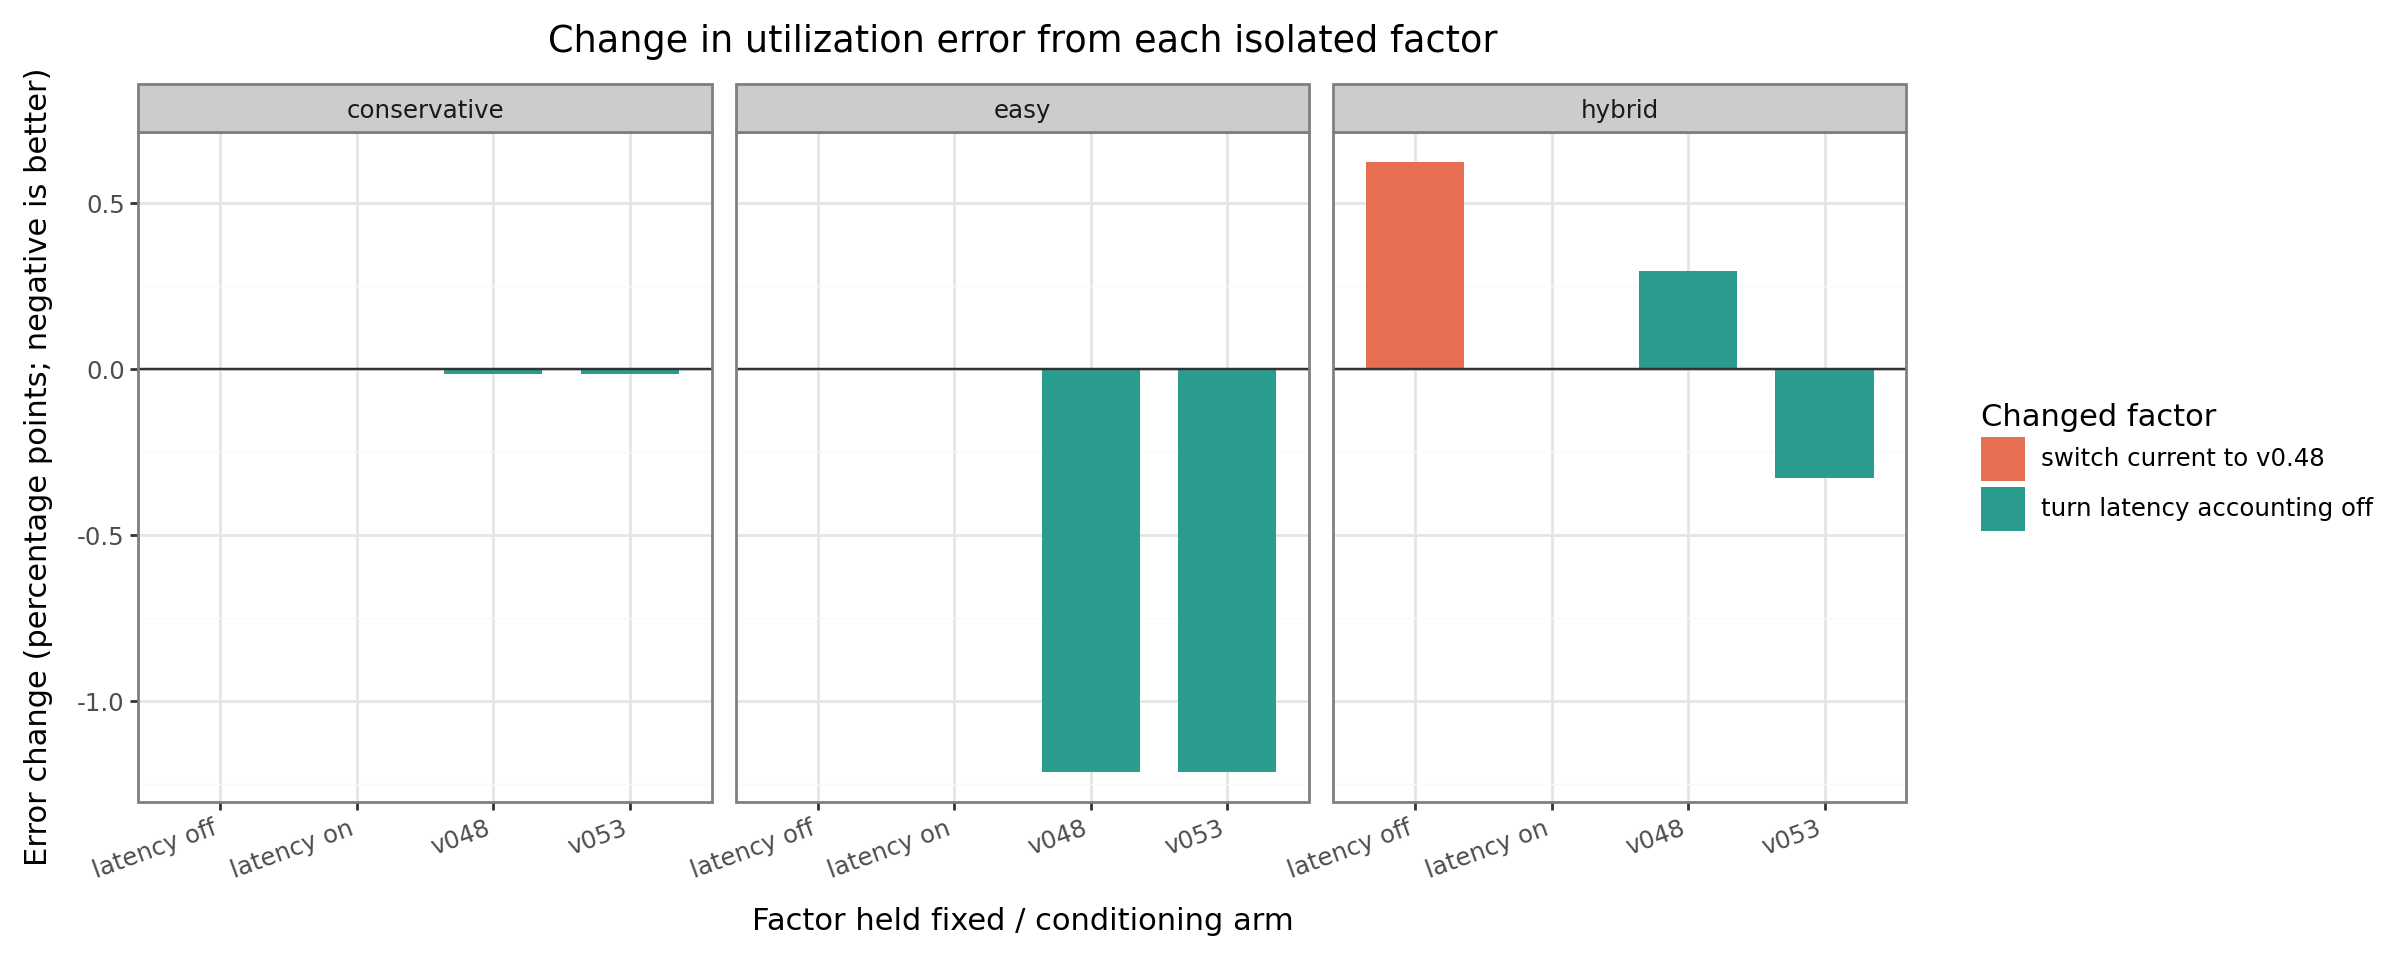

In [3]:
effects = pd.DataFrame(payload['factor_effects'])
display(effects.round(4))

effect_plot = effects.copy()
effect_plot['comparison'] = effect_plot['factor'].map({
    'turn_account_system_latency_off': 'turn latency accounting off',
    'switch_v053_to_v048': 'switch current to v0.48',
})
effect_plot['condition'] = effect_plot.apply(
    lambda row: row.get('scheduler_base')
    if pd.notna(row.get('scheduler_base'))
    else ('latency on' if row.get('account_system_latency') else 'latency off'),
    axis=1,
)
(
    ggplot(effect_plot, aes('condition', 'error_change_pp', fill='comparison'))
    + geom_col(position=position_dodge(width=0.8), width=0.72)
    + geom_hline(yintercept=0.0, color='#333333')
    + facet_wrap('~policy', nrow=1)
    + scale_fill_manual(values={
        'turn latency accounting off': '#2A9D8F',
        'switch current to v0.48': '#E76F51',
    })
    + labs(
        title='Change in utilization error from each isolated factor',
        x='Factor held fixed / conditioning arm',
        y='Error change (percentage points; negative is better)',
        fill='Changed factor',
    )
    + theme_bw()
    + theme(
        figure_size=(12, 4.8),
        axis_text_x=element_text(rotation=20, ha='right'),
    )
)


## Runtime and trace integrity

Wall time is diagnostic rather than an accuracy metric. Every arm
used O3 and DFTracer level 2, and each trace was accepted only after
finding `run_match` events carrying job IDs.


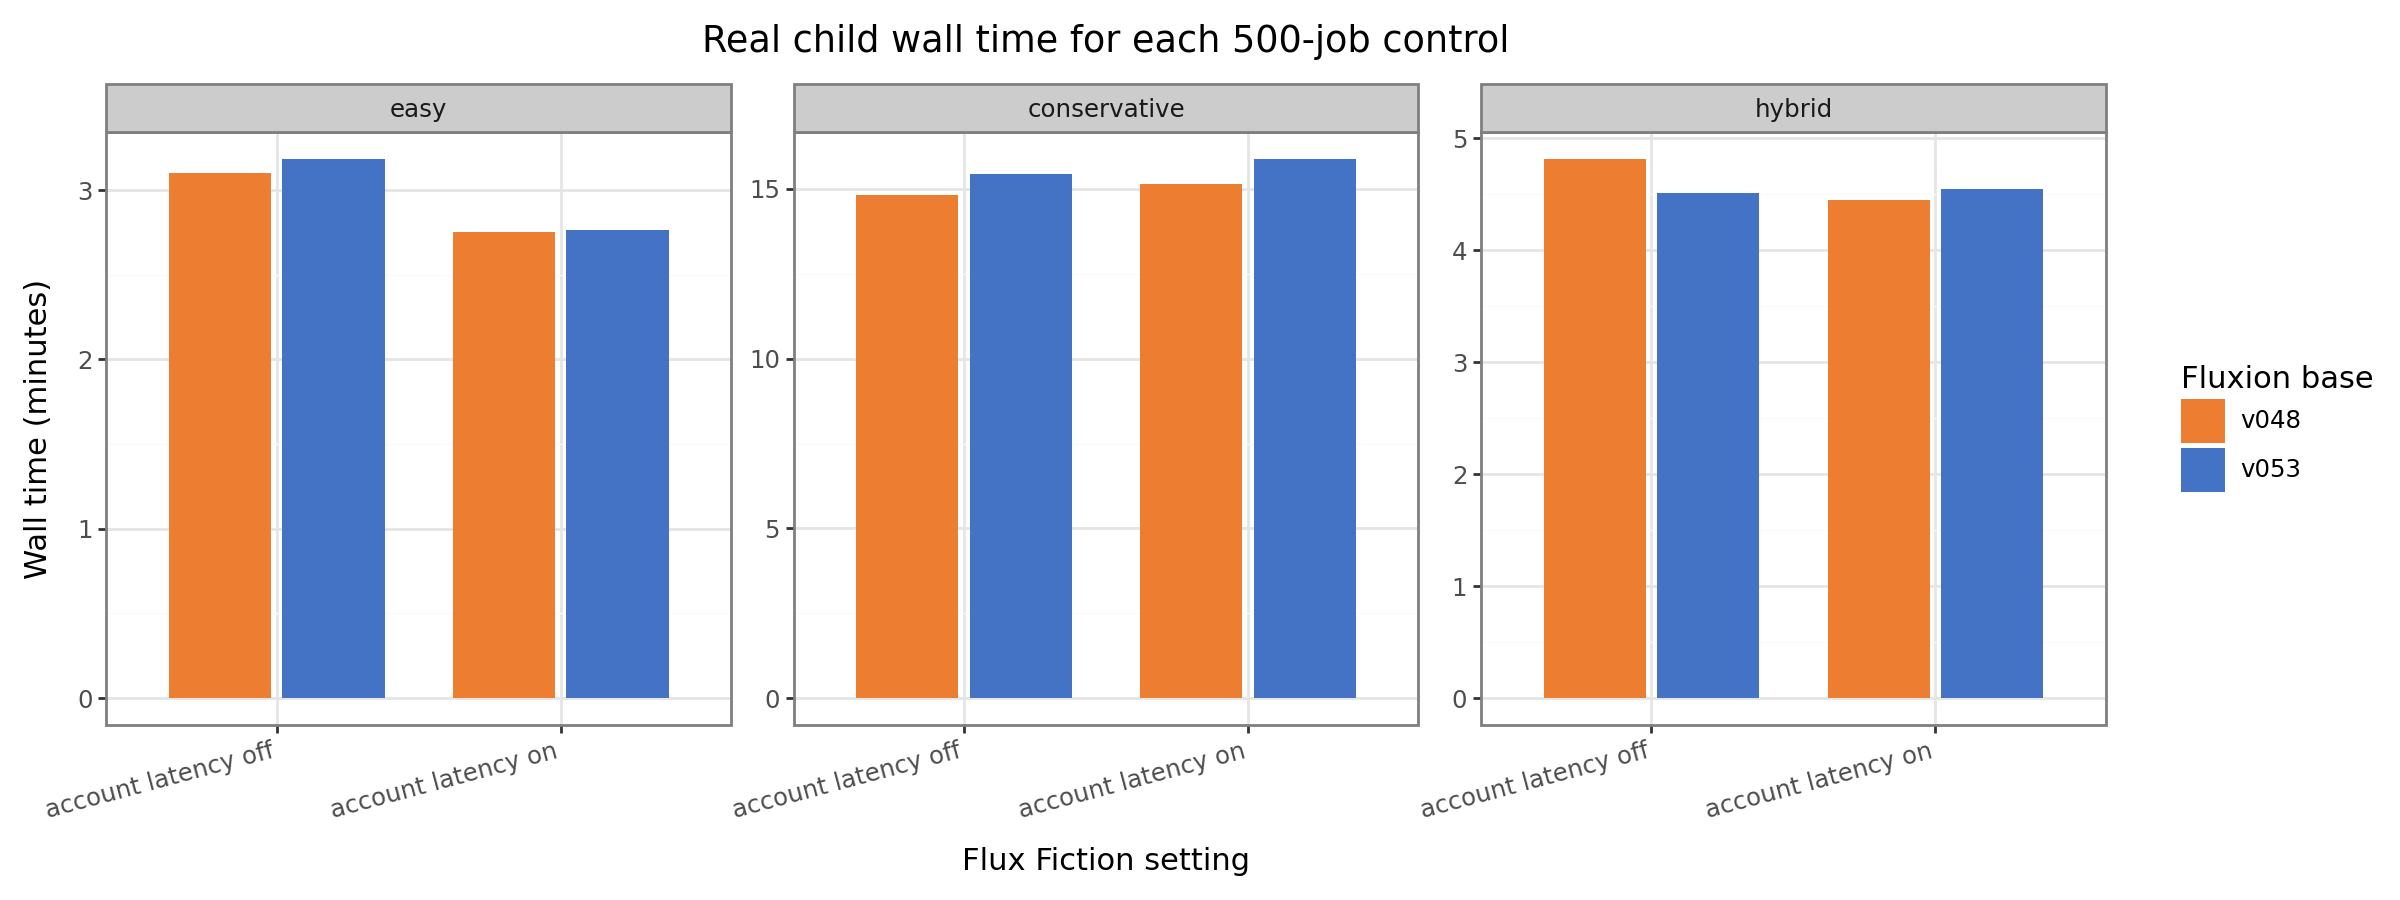

In [4]:
runs['wall_minutes'] = runs['wall_seconds'] / 60.0
(
    ggplot(runs, aes('latency_setting', 'wall_minutes', fill='scheduler_base'))
    + geom_col(position=position_dodge(width=0.8), width=0.72)
    + facet_wrap('~policy', nrow=1, scales='free_y')
    + scale_fill_manual(values={'v053': '#4472C4', 'v048': '#ED7D31'})
    + labs(
        title='Real child wall time for each 500-job control',
        x='Flux Fiction setting', y='Wall time (minutes)', fill='Fluxion base',
    )
    + theme_bw()
    + theme(
        figure_size=(12, 4.5),
        axis_text_x=element_text(rotation=15, ha='right'),
    )
)


## Findings

- **Easy** — current: latency on `1.385` pp, off `0.174` pp; v0.48: on `1.385` pp, off `0.174` pp.
- **Conservative** — current: latency on `0.240` pp, off `0.225` pp; v0.48: on `0.240` pp, off `0.225` pp.
- **Hybrid** — current: latency on `0.769` pp, off `0.441` pp; v0.48: on `0.769` pp, off `1.064` pp.
- Every arm completed 500/500 jobs and every merged trace retained `run_match` job-ID metadata.
- The lowest observed error was **0.174 pp** for `v053-easy-latency-off`.
- These are paired controls under the modified shared clock and level-2 DFTracer. They isolate the requested factors; they do not test synchronous submission.
